# Neural Networks: The Multi-Layer Perceptron (MLP)

**Flow:** a problem a linear model cannot solve → what an MLP adds (hidden layers + non-linear activations) → why scaling is mandatory → watching the loss converge → tuning capacity/regularization with CV → held-out evaluation → the caveats.

A **multi-layer perceptron** stacks linear layers with non-linear activations, letting it approximate complex decision boundaries and regression surfaces that a single linear model cannot. That flexibility costs interpretability, needs feature scaling, is sensitive to hyperparameters, and can overfit. We demonstrate both classification and regression, always splitting before fitting and scoring once on held-out data.


## 1. Setup and versions

In [1]:
import sys
import numpy as np
import scipy
import sklearn
import matplotlib
import matplotlib.pyplot as plt

# Colorblind-safe Okabe-Ito categorical palette used throughout this curriculum.
OKABE_ITO = [
    '#0072B2',  # blue
    '#E69F00',  # orange
    '#009E73',  # bluish green
    '#D55E00',  # vermillion
    '#CC79A7',  # reddish purple
    '#56B4E9',  # sky blue
    '#F0E442',  # yellow
    '#000000',  # black
]
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('Python      :', sys.version.split()[0])
print('numpy       :', np.__version__)
print('scipy       :', scipy.__version__)
print('scikit-learn:', sklearn.__version__)
print('matplotlib  :', matplotlib.__version__)


Python      : 3.9.25
numpy       : 1.26.4
scipy       : 1.13.1
scikit-learn: 1.4.2
matplotlib  : 3.8.4


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, r2_score, mean_squared_error

rng = np.random.default_rng(51)


## 2. A non-linearly-separable classification problem
We build two interleaving spirals — a classic case where a linear classifier fails. Split before fitting. We will show a linear baseline struggling and the MLP succeeding.

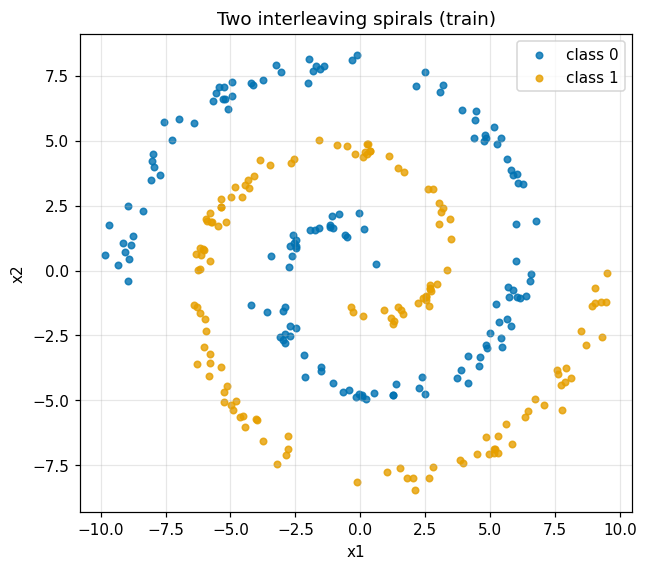

In [3]:
def make_spirals(rng, n=400, noise=0.25):
    n2 = n // 2
    t = np.sqrt(rng.uniform(0, 1, size=n2)) * 3 * np.pi
    r = t
    x1 = np.c_[r * np.cos(t), r * np.sin(t)] + rng.normal(0, noise, (n2, 2))
    x2 = np.c_[-r * np.cos(t), -r * np.sin(t)] + rng.normal(0, noise, (n2, 2))
    X = np.vstack([x1, x2])
    y = np.array([0] * n2 + [1] * n2)
    return X, y

Xc, yc = make_spirals(rng)
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(Xc, yc, test_size=0.3,
                                              random_state=0, stratify=yc)
fig, ax = plt.subplots(figsize=(6, 6))
for g in [0, 1]:
    ax.scatter(Xc_tr[yc_tr == g, 0], Xc_tr[yc_tr == g, 1],
               s=18, color=OKABE_ITO[g], alpha=0.8, label=f'class {g}')
ax.set_xlabel('x1'); ax.set_ylabel('x2'); ax.set_title('Two interleaving spirals (train)')
ax.legend(); ax.set_aspect('equal'); plt.tight_layout(); plt.show()


## 3. Scaling is mandatory; compare linear vs. MLP decision boundaries
Neural nets rely on gradient descent, which behaves poorly on unscaled inputs, so we standardize inside a pipeline. We fit a linear (logistic) baseline and an MLP, then plot their decision regions.

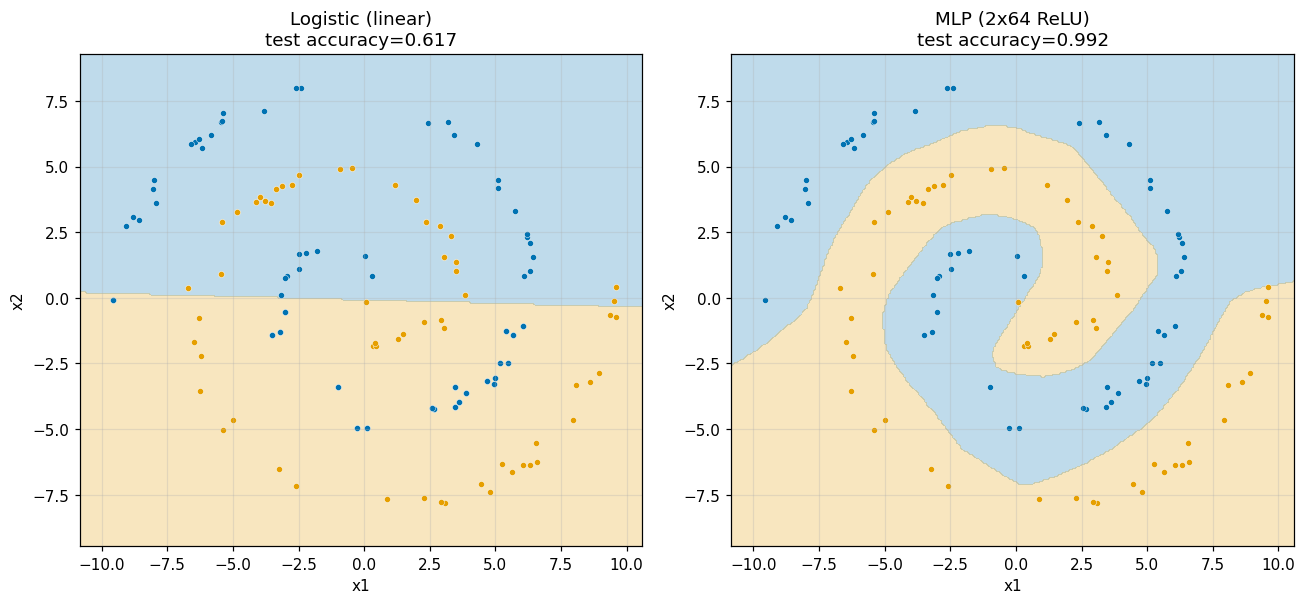

In [4]:
linear_clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(Xc_tr, yc_tr)
mlp_clf = make_pipeline(
    StandardScaler(),
    MLPClassifier(hidden_layer_sizes=(64, 64), activation='relu', alpha=1e-3,
                  max_iter=2000, random_state=0)
).fit(Xc_tr, yc_tr)

xx, yy = np.meshgrid(np.linspace(Xc[:, 0].min() - 1, Xc[:, 0].max() + 1, 300),
                     np.linspace(Xc[:, 1].min() - 1, Xc[:, 1].max() + 1, 300))
gridpts = np.c_[xx.ravel(), yy.ravel()]
fig, ax = plt.subplots(1, 2, figsize=(12, 5.5))
for a, (name, mdl) in zip(ax, [('Logistic (linear)', linear_clf), ('MLP (2x64 ReLU)', mlp_clf)]):
    zz = mdl.predict(gridpts).reshape(xx.shape)
    a.contourf(xx, yy, zz, alpha=0.25, colors=[OKABE_ITO[0], OKABE_ITO[1]], levels=[-0.5, 0.5, 1.5])
    for g in [0, 1]:
        a.scatter(Xc_te[yc_te == g, 0], Xc_te[yc_te == g, 1],
                  s=16, color=OKABE_ITO[g], edgecolor='white', linewidth=0.3)
    acc = accuracy_score(yc_te, mdl.predict(Xc_te))
    a.set_title(f'{name}\ntest accuracy={acc:.3f}')
    a.set_xlabel('x1'); a.set_ylabel('x2'); a.set_aspect('equal')
plt.tight_layout(); plt.show()


## 4. Watching convergence (the loss curve)
`MLPClassifier` stores the training loss per iteration in `loss_curve_`. Plotting it shows the optimizer converging. A curve that is still falling steeply means training stopped too early (raise `max_iter`); a flat curve means it converged.

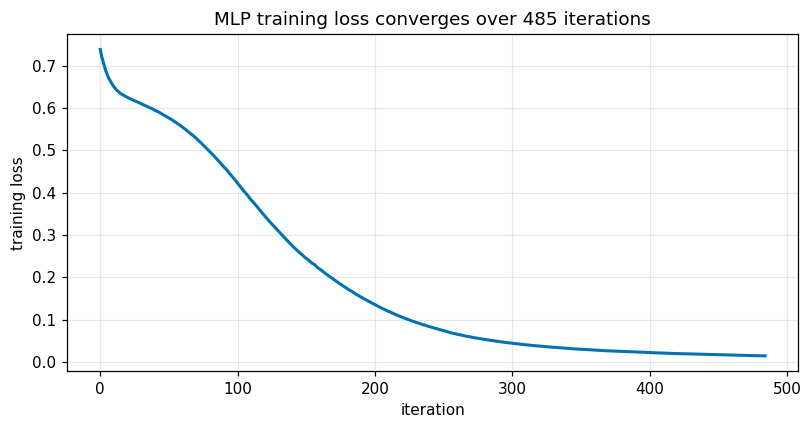

Final training loss: 0.0143
Held-out accuracy: 0.992   ROC AUC: 1.000


In [5]:
raw_mlp = mlp_clf.named_steps['mlpclassifier']
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(raw_mlp.loss_curve_, color=OKABE_ITO[0], lw=2)
ax.set_xlabel('iteration'); ax.set_ylabel('training loss')
ax.set_title(f'MLP training loss converges over {len(raw_mlp.loss_curve_)} iterations')
plt.tight_layout(); plt.show()
print(f'Final training loss: {raw_mlp.loss_curve_[-1]:.4f}')
print(f'Held-out accuracy: {accuracy_score(yc_te, mlp_clf.predict(Xc_te)):.3f}   '
      f'ROC AUC: {roc_auc_score(yc_te, mlp_clf.predict_proba(Xc_te)[:, 1]):.3f}')


## 5. Tune capacity and regularization with cross-validation
The hidden-layer size (capacity) and `alpha` (L2 regularization) control over/underfitting. We select them with stratified k-fold cross-validation on the training data — never the test set.

In [6]:
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=1)
pipe = make_pipeline(StandardScaler(),
                     MLPClassifier(activation='relu', max_iter=2000, random_state=0))
grid = {
    'mlpclassifier__hidden_layer_sizes': [(16,), (64,), (64, 64)],
    'mlpclassifier__alpha': [1e-4, 1e-2, 1e-1],
}
search = GridSearchCV(pipe, grid, cv=cv, scoring='accuracy', n_jobs=-1).fit(Xc_tr, yc_tr)
print('Best params:', search.best_params_)
print(f'Best CV accuracy: {search.best_score_:.3f}')
print(f'Held-out test accuracy of tuned MLP: {accuracy_score(yc_te, search.predict(Xc_te)):.3f}')


Best params: {'mlpclassifier__alpha': 0.01, 'mlpclassifier__hidden_layer_sizes': (64, 64)}
Best CV accuracy: 0.989
Held-out test accuracy of tuned MLP: 0.992


## 6. MLP for regression
`MLPRegressor` fits smooth non-linear regression surfaces. We reuse a curved 1-D signal, scale inputs, and compare the MLP fit and its convergence to a held-out score.

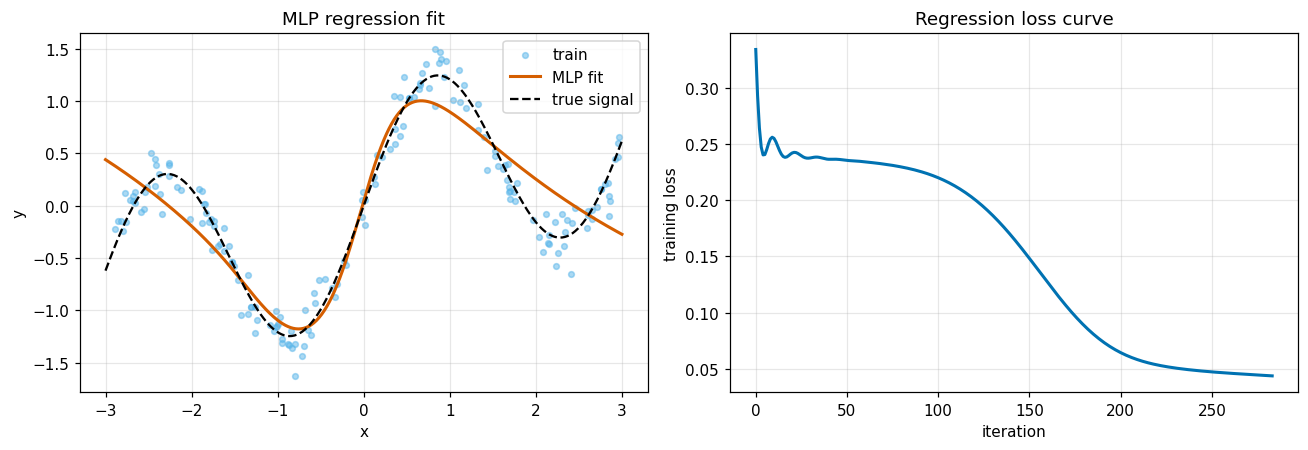

MLP regression test R^2=0.902  RMSE=0.246


/home/ec2-user/.local/lib/python3.9/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [7]:
xr = np.sort(rng.uniform(-3, 3, size=250))
yr = np.sin(2 * xr) + 0.3 * xr + rng.normal(0, 0.15, size=xr.size)
Xr = xr[:, None]
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(Xr, yr, test_size=0.3, random_state=0)

mlp_reg = make_pipeline(
    StandardScaler(),
    MLPRegressor(hidden_layer_sizes=(64, 64), activation='tanh', alpha=1e-3,
                 max_iter=4000, random_state=0)
).fit(Xr_tr, yr_tr)
gr = np.linspace(-3, 3, 400)[:, None]
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].scatter(Xr_tr[:, 0], yr_tr, s=14, color=OKABE_ITO[5], alpha=0.5, label='train')
ax[0].plot(gr[:, 0], mlp_reg.predict(gr), color=OKABE_ITO[3], lw=2, label='MLP fit')
ax[0].plot(gr[:, 0], np.sin(2 * gr[:, 0]) + 0.3 * gr[:, 0], color=OKABE_ITO[7],
           ls='--', lw=1.5, label='true signal')
ax[0].set_xlabel('x'); ax[0].set_ylabel('y'); ax[0].set_title('MLP regression fit'); ax[0].legend()
ax[1].plot(mlp_reg.named_steps['mlpregressor'].loss_curve_, color=OKABE_ITO[0], lw=2)
ax[1].set_xlabel('iteration'); ax[1].set_ylabel('training loss'); ax[1].set_title('Regression loss curve')
plt.tight_layout(); plt.show()
p = mlp_reg.predict(Xr_te)
print(f'MLP regression test R^2={r2_score(yr_te, p):.3f}  RMSE={mean_squared_error(yr_te, p, squared=False):.3f}')


## Key takeaways and caveats

- **MLPs model non-linearities** a single linear model cannot (e.g., spirals), thanks to hidden layers and non-linear activations.
- **Always scale inputs.** Gradient-based training is sensitive to feature scale; put `StandardScaler` in a `Pipeline`.
- **Watch `loss_curve_`.** A still-falling curve means increase `max_iter`; a flat curve means it converged. Convergence warnings are signals, not decoration.
- **Tune capacity and `alpha` with CV.** Bigger networks overfit; L2 (`alpha`) regularizes. Never tune on the test set.
- **Caveats:** MLPs are far less interpretable than linear models, sensitive to seeds and hyperparameters, and data-hungry. For small tabular problems, regularized linear models or gradient-boosted trees are often stronger and simpler baselines. Reach for a neural net when the extra flexibility is justified.
